In [1]:
import sys
from pathlib import Path
import pandas as pd
from sqlalchemy import text
from src.db.engine import get_engine       
from scipy import stats
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from src.db.engine import get_engine       
from config import get_config 

project_root = Path.cwd().parent


if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")  

ModuleNotFoundError: No module named 'src'

In [ ]:
# Connect and Check

engine = get_engine()
config = get_config()

with engine.connect() as conn:
    result = conn.execute(text("SELECT current_database(), current_user;"))
    db, user = result.fetchone()
    print(f"Connected to: {db} as {user}")
    print(f"Host: {config.db.host}:{config.db.port}")

2026-02-17 14:48:47 - src.db.engine - INFO - Creating database engine for localhost:5432/bulls
2026-02-17 14:48:48 - src.db.engine - INFO - Database engine created successfully
Connected to: bulls as postgres
Host: localhost:5432


In [ ]:
sql = """ 
        SELECT
        	lgl.game_id, 
        	lgl.group_id,
        	lgl.group_name, 
        	lgl.opponent_team_id, 
        	lgl.min, 
        	lgl.plus_minus, 
        	lgl.pts, 
        	lgl.fgm, 
        	lgl.fga, 
        	lgl.fg_pct, 
        	lgl.fg3m, 
        	lgl.fg3a, 
        	lgl.fg3_pct,
        	lgl.ftm, 
        	lgl.fta, 
        	lgl.ft_pct, 
        	lgl.reb, 
        	lgl.ast, 
        	lgl.tov, 
        	lgl.stl,
        	lgl.blk, 
        	lgl.pf, 
        	fg.home_team_id, 
        	fg.away_team_id
        FROM nba.lineup_game_logs lgl
        JOIN nba.fact_games fg
        	ON lgl.game_id = fg.game_id
        WHERE lgl.min >= 0.5;  """

with engine.connect() as conn:
    df = pd.read_sql(sql, conn)

print(f"Loaded {len(df):,} stints across {df['game_id'].nunique()} games")
df.head()

Loaded 196 stints across 13 games


,game_id,group_id,group_name,opponent_team_id,min,plus_minus,pts,fgm,fga,fg_pct,...,fta,ft_pct,reb,ast,tov,stl,blk,pf,home_team_id,away_team_id
0,0022500463,-203497-203944-1628978-1630162-1641740-,Gobert; Randle; DiVincenzo; Edwards; Clark,1610612737,4.083333,-1,8,3,10,0.300,...,2,1.0,5,3,2,2,1,0,1610612737,1610612750
1,0022500463,-204060-1630548-1631159-1642265-1642866-,Ingles; Juzang; Miller; Dillingham; Beringer,1610612737,3.683333,1,10,4,6,0.667,...,0,0.0,3,2,1,0,0,0,1610612737,1610612750
2,0022500463,-201144-203497-1629675-1630162-1641740-,Conley; Gobert; Reid; Edwards; Clark,1610612737,3.650000,-5,2,1,7,0.143,...,0,0.0,4,0,1,1,0,1,1610612737,1610612750
3,0022500463,-203497-203944-1628978-1629675-1630162-,Gobert; Randle; DiVincenzo; Reid; Edwards,1610612737,2.900000,-4,7,3,5,0.600,...,0,0.0,2,2,1,0,0,0,1610612737,1610612750
4,0022500463,-201144-203497-1629675-1630183-1630538-,Conley; Gobert; Reid; McDaniels; Hyland,1610612737,2.800000,-10,2,0,5,0.000,...,2,1.0,2,0,1,0,1,1,1610612737,1610612750


In [ ]:
total_stints = 196
randle_stints = (df['group_name'].str.contains('Randle').astype(bool)).sum()
ried_stints = (df['group_name'].str.contains('Reid').astype(bool)).sum()
randle_ried_stints = ((df['group_name'].str.contains('Randle').astype(bool)) &
                      (df['group_name'].str.contains('Reid').astype(bool))).sum()
print("Total: ", total_stints)
print("Randle: ", randle_stints)
print("Ried: ", ried_stints)
print("Both: ", randle_ried_stints)

Total:  196
Randle:  123
Ried:  124
Both:  71


In [ ]:
has_randle = df['group_name'].str.contains('Randle')
has_reid   = df['group_name'].str.contains('Reid')
has_both   = has_randle & has_reid

total_games = 13
randle_games = df.loc[has_randle, 'game_id'].nunique()
reid_games = df.loc[has_reid, 'game_id'].nunique()
both_games = df.loc[has_both, 'game_id'].nunique()

print('Total games with lineup data:' , total_games)
print('Randle games:', randle_games)
print('Reid games:', reid_games)
print('Both games:', both_games)


Total games: 13
Randle games: 13
Reid games: 13
Both games: 13


In [ ]:
""" Both players appeared together and individually in every game but we only have 
    13/56 games (at the time of doing this inference) available to us so I will be
    checking for differences in key statistics of the teams they did play vs the teams
    they did not play """

In [ ]:
teams_played_sql = """ 
                    SELECT 
                    	DISTINCT team.team_name, 
                        team.team_id
                    FROM nba.dim_teams team
                    JOIN nba.lineup_game_logs lineup
                    	ON team.team_id = lineup.opponent_team_id
                    """

with engine.connect() as conn:
    teams_played = pd.read_sql(teams_played_sql, conn)  
print(teams_played)

    team_name     team_id
0     Celtics  1610612738
1     Rockets  1610612745
2     Hornets  1610612766
3       Hawks  1610612737
4     Wizards  1610612764
5    Clippers  1610612746
6    Warriors  1610612744
7   Cavaliers  1610612739
8        Heat  1610612748
9       Kings  1610612758
10     Pacers  1610612754
11  Mavericks  1610612742


In [ ]:
teams_notplayed_sql = """ 
                        SELECT 
                        	DISTINCT team.team_name,
                            team.team_id
                        FROM nba.dim_teams team
                        LEFT JOIN nba.lineup_game_logs lineup
                        	ON team.team_id = lineup.opponent_team_id
                        WHERE lineup.opponent_team_id IS NULL
                            
                    """
with engine.connect() as conn:
    teams_notplayed = pd.read_sql(teams_notplayed_sql, conn)  
print(teams_notplayed)

        team_name     team_id
0          Lakers  1610612747
1            Nets  1610612751
2    Timberwolves  1610612750
3            Suns  1610612756
4           Bucks  1610612749
5         Thunder  1610612760
6       Grizzlies  1610612763
7   Trail Blazers  1610612757
8         Raptors  1610612761
9         Pistons  1610612765
10        Nuggets  1610612743
11          Spurs  1610612759
12         Knicks  1610612752
13           Jazz  1610612762
14          76ers  1610612755
15       Pelicans  1610612740
16          Magic  1610612753
17          Bulls  1610612741


In [ ]:
teams_ratings_sql = """ 
                    SELECT
                    team_id, 
                    ROUND(AVG(net_rating)::numeric, 1) AS net_rating,
                    ROUND(AVG(off_rating)::numeric, 1) AS off_rating,
                    ROUND(AVG(def_rating)::numeric, 1) AS def_rating
                    FROM nba.teambox_pergame
                    GROUP BY team_id
                    """

with engine.connect() as conn:
    teams_ratings = pd.read_sql(teams_ratings_sql, conn)  
print(teams_ratings)

       team_id  net_rating  off_rating  def_rating
0   1610612752         6.3       118.8       112.5
1   1610612744         2.0       114.4       112.4
2   1610612762        -7.5       113.7       121.4
3   1610612747        -0.4       116.3       116.7
4   1610612737        -1.2       113.6       114.8
5   1610612743         4.0       120.9       116.9
6   1610612750         4.0       116.8       112.8
7   1610612758       -10.2       109.7       119.9
8   1610612751        -7.4       110.6       118.1
9   1610612739         4.1       117.5       113.3
10  1610612738         7.5       120.2       112.7
11  1610612753        -0.1       113.4       113.6
12  1610612749        -2.8       113.0       115.8
13  1610612757        -1.7       113.7       115.4
14  1610612748         2.1       113.9       111.8
15  1610612765         8.2       116.6       108.5
16  1610612746        -0.3       115.5       115.8
17  1610612756         1.9       114.8       112.9
18  1610612760        11.5     

In [ ]:
teams_played_ratings = teams_ratings[teams_ratings['team_id'].isin(teams_played['team_id'])]
print('Played:')
print(teams_played_ratings)

teams_notplayed_ratings = teams_ratings[teams_ratings['team_id'].isin(teams_notplayed['team_id'])]
print('Did Not Play:' )
print(teams_notplayed_ratings)

Played:
       team_id  net_rating  off_rating  def_rating
1   1610612744         2.0       114.4       112.4
4   1610612737        -1.2       113.6       114.8
7   1610612758       -10.2       109.7       119.9
9   1610612739         4.1       117.5       113.3
10  1610612738         7.5       120.2       112.7
14  1610612748         2.1       113.9       111.8
16  1610612746        -0.3       115.5       115.8
19  1610612766         1.6       116.4       114.8
20  1610612764       -11.1       109.4       120.5
22  1610612742        -3.4       110.3       113.6
24  1610612754        -7.4       108.9       116.2
27  1610612745         5.0       117.1       112.0
Did Not Play:
       team_id  net_rating  off_rating  def_rating
0   1610612752         6.3       118.8       112.5
2   1610612762        -7.5       113.7       121.4
3   1610612747        -0.4       116.3       116.7
5   1610612743         4.0       120.9       116.9
6   1610612750         4.0       116.8       112.8
8   16106

In [ ]:
stats_to_test = ["net_rating", "off_rating", "def_rating"]

def cohens_d(a, b):
    pooled_std = np.sqrt((a.std()**2 + b.std()**2) / 2)
    return (a.mean() - b.mean()) / pooled_std if pooled_std > 0 else 0.0

print(f"{'Statistic':<15} {'Played Mean':>12} {'Not Played Mean':>16} {'U stat':>8} {'p-value':>9} {'Cohen d':>9}")
print("-" * 75)

for col in stats_to_test:
    a = teams_played_ratings[col]
    b = teams_notplayed_ratings[col]
    u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    d = cohens_d(a, b)
    print(f"{col:<15} {a.mean():>12.2f} {b.mean():>16.2f} {u:>8.1f} {p:>9.4f} {d:>9.3f}")

Statistic        Played Mean  Not Played Mean   U stat   p-value   Cohen d
---------------------------------------------------------------------------
net_rating             -0.94             0.61     99.5    0.7348    -0.274
off_rating            113.91           115.01     95.5    0.6114    -0.347
def_rating            114.82           114.44    105.0    0.9157     0.114


In [ ]:
print(len(teams_notplayed_ratings)) 

print(len(teams_played_ratings))


In [ ]:
"Despite unbalanced groups no statistical rating differences found between teams played vs teams not played"

In [ ]:
df['randle'] = df['group_name'].str.contains('Randle').astype(int)
df['reid']   = df['group_name'].str.contains('Reid').astype(int)
df['randle_reid'] = df['randle'] * df['reid']

In [ ]:


model = smf.wls(
    "plus_minus ~ randle + reid + randle_reid + C(opponent_team_id)",
    data=df,
    weights=df["min"]
)

res = model.fit(cov_type="cluster", cov_kwds={"groups": df["game_id"]})
print(res.summary())


                            WLS Regression Results                            
Dep. Variable:             plus_minus   R-squared:                       0.144
Model:                            WLS   Adj. R-squared:                  0.078
Method:                 Least Squares   F-statistic:                     5.284
Date:                Tue, 17 Feb 2026   Prob (F-statistic):             0.0109
Time:                        16:21:49   Log-Likelihood:                -682.75
No. Observations:                 196   AIC:                             1395.
Df Residuals:                     181   BIC:                             1445.
Df Model:                          14                                         
Covariance Type:              cluster                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

C:\Projects\bulls-analytics\.venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 14, but rank is 4
  warnings.warn('covariance of constraints does not have full '


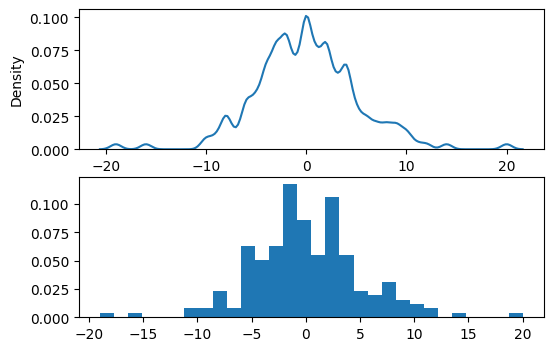

In [ ]:
fig, axes = plt.subplots(2, 1, figsize = (6,4))
sns.kdeplot(df['plus_minus'], bw_adjust=.3, ax=axes[0])
axes[1].hist(df['plus_minus'], bins=30, density=True)
plt.show()

C:\Users\jacob\AppData\Local\Temp\ipykernel_25544\3899372471.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,1].boxplot(


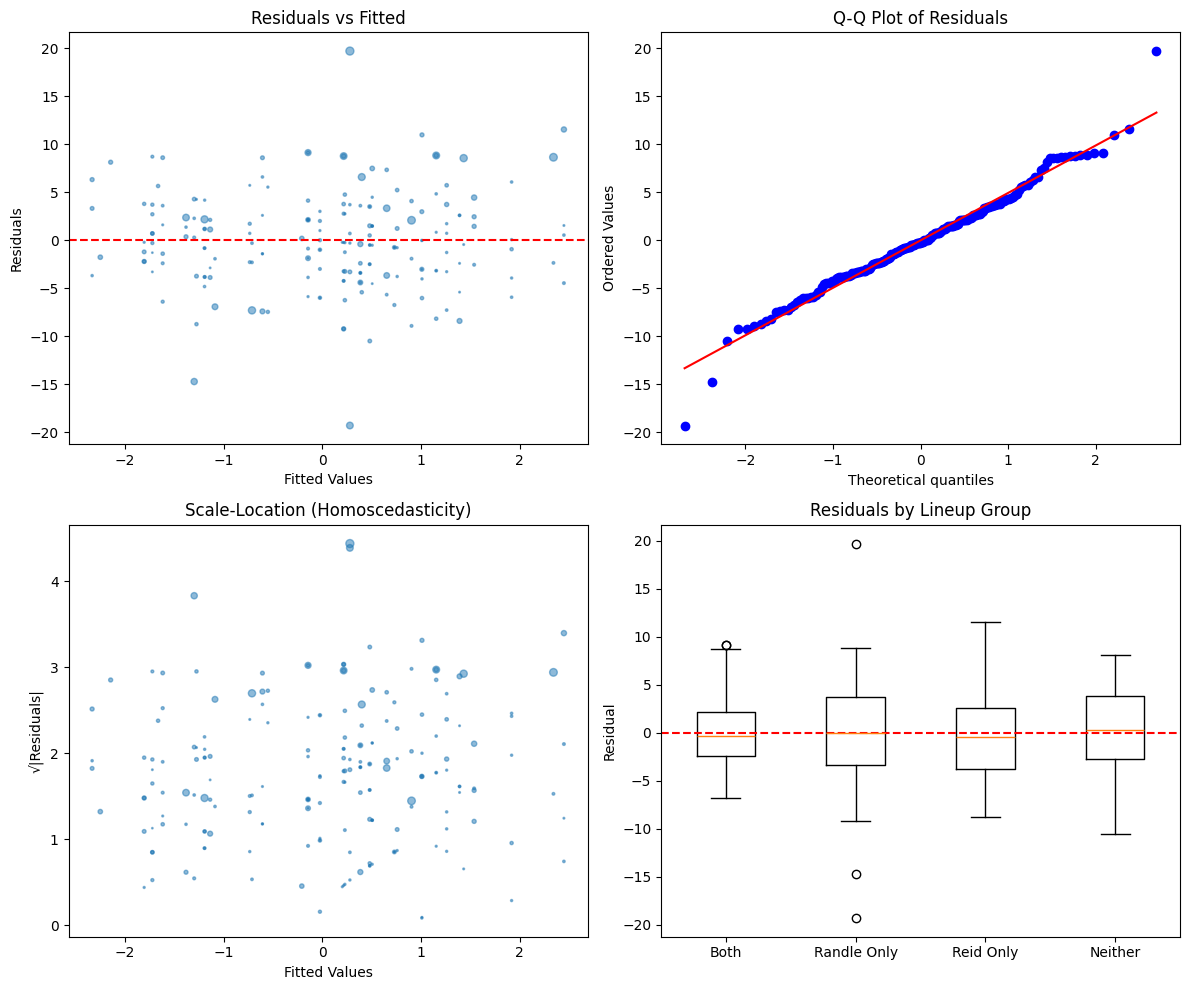

Breusch-Pagan: stat=19.941, p=0.1320
Homoscedastic — SEs valid either way


In [ ]:
fitted = res.fittedvalues
resid  = res.resid
weights = df["min"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Residuals vs Fitted — checks linearity and homoscedasticity
axes[0,0].scatter(fitted, resid, alpha=0.5, s=weights*2)
axes[0,0].axhline(0, color='red', linestyle='--')
axes[0,0].set_xlabel("Fitted Values")
axes[0,0].set_ylabel("Residuals")
axes[0,0].set_title("Residuals vs Fitted")

# 2. Q-Q Plot — checks normality of residuals (expect deviation given JB result)
stats.probplot(resid, dist="norm", plot=axes[0,1])
axes[0,1].set_title("Q-Q Plot of Residuals")

# 3. Scale-Location — checks homoscedasticity
axes[1,0].scatter(fitted, np.sqrt(np.abs(resid)), alpha=0.5, s=weights*2)
axes[1,0].set_xlabel("Fitted Values")
axes[1,0].set_ylabel("√|Residuals|")
axes[1,0].set_title("Scale-Location (Homoscedasticity)")

# 4. Residuals by lineup group — key diagnostic for your hypothesis
df["resid"] = resid.values
groups = {
    "Both":        df["randle_reid"] == 1,
    "Randle Only": (df["randle"] == 1) & (df["randle_reid"] == 0),
    "Reid Only":   (df["reid"]   == 1) & (df["randle_reid"] == 0),
    "Neither":     (df["randle"] == 0) & (df["reid"] == 0),
}
axes[1,1].boxplot(
    [df.loc[mask, "resid"].values for mask in groups.values()],
    labels=groups.keys()
)
axes[1,1].axhline(0, color='red', linestyle='--')
axes[1,1].set_title("Residuals by Lineup Group")
axes[1,1].set_ylabel("Residual")

plt.tight_layout()
plt.show()

# Breusch-Pagan formal heteroscedasticity test
from statsmodels.stats.diagnostic import het_breuschpagan
bp_stat, bp_p, _, _ = het_breuschpagan(resid, res.model.exog)
print(f"Breusch-Pagan: stat={bp_stat:.3f}, p={bp_p:.4f}")
print("HC3/cluster SEs are warranted" if bp_p < 0.05 else "Homoscedastic — SEs valid either way")

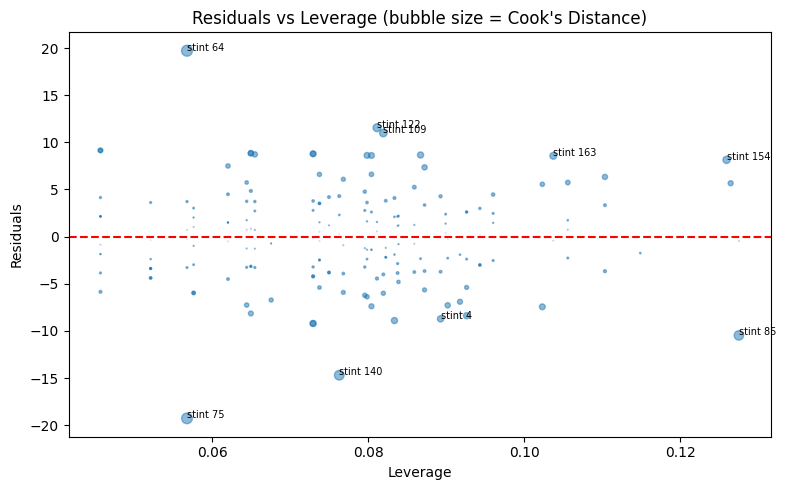

High influence stints (Cook's D > 0.020): 9
Max Cook's Distance: 0.0624


In [ ]:
from statsmodels.stats.outliers_influence import OLSInfluence
import numpy as np
import matplotlib.pyplot as plt

# OLSInfluence works on the underlying OLS model object
influence = OLSInfluence(res)
leverage  = influence.hat_matrix_diag
cooks_d   = influence.cooks_distance[0]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(leverage, res.resid, s=cooks_d * 1000, alpha=0.5)
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel("Leverage")
ax.set_ylabel("Residuals")
ax.set_title("Residuals vs Leverage (bubble size = Cook's Distance)")

# Mark high-influence points (Cook's D > 4/n threshold)
threshold = 4 / len(res.resid)
high_influence = np.where(cooks_d > threshold)[0]
for i in high_influence:
    ax.annotate(f"stint {i}", (leverage[i], res.resid.iloc[i]), fontsize=7)

plt.tight_layout()
plt.show()

print(f"High influence stints (Cook's D > {threshold:.3f}): {len(high_influence)}")
print(f"Max Cook's Distance: {cooks_d.max():.4f}")

In [ ]:
high_lev_stints = df.iloc[[85, 154]][
    ['game_id', 'group_name', 'min', 'plus_minus', 'opponent_team_id']
]
print(high_lev_stints)

        game_id                                    group_name       min  \
85   0022500677  Ingles; Juzang; Miller; Dillingham; Beringer  3.466667   
154  0022500760    Ingles; Clark; Phillips; Freeman; Beringer  4.216667   

     plus_minus  opponent_team_id  
85          -10        1610612742  
154           6        1610612746  


In [ ]:
# Refit the model dropping the two high-leverage stints
df_sensitivity = df.drop(index=[85, 154])

model_sens = smf.wls(
    "plus_minus ~ randle + reid + randle_reid + C(opponent_team_id)",
    data=df_sensitivity,
    weights=df_sensitivity["min"]
)
res_sens = model_sens.fit(cov_type="cluster", cov_kwds={"groups": df_sensitivity["game_id"]})

# Compare the key coefficient
orig  = res.params["randle_reid"]
sens  = res_sens.params["randle_reid"]
print(f"randle_reid coefficient — Original: {orig:.4f}  |  Without stints 85 & 154: {sens:.4f}")
print(f"Change: {sens - orig:.4f}")
res_sens.summary()

randle_reid coefficient — Original: -1.4811  |  Without stints 85 & 154: -3.4043
Change: -1.9232


C:\Projects\bulls-analytics\.venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 14, but rank is 4
  warnings.warn('covariance of constraints does not have full '


<class 'statsmodels.iolib.summary.Summary'>
"""
                            WLS Regression Results                            
==============================================================================
Dep. Variable:             plus_minus   R-squared:                       0.159
Model:                            WLS   Adj. R-squared:                  0.093
Method:                 Least Squares   F-statistic:                     3.872
Date:                Tue, 17 Feb 2026   Prob (F-statistic):             0.0303
Time:                        17:20:58   Log-Likelihood:                -673.95
No. Observations:                 194   AIC:                             1378.
Df Residuals:                     179   BIC:                             1427.
Df Model:                          14                                         
Covariance Type:              cluster                                         
=====================================================================================================
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                            -3.3731      2.176     -1.550      0.121      -7.639       0.893
C(opponent_team_id)[T.1610612738]     2.9767      0.354      8.398      0.000       2.282       3.671
C(opponent_team_id)[T.1610612739]    -1.8750      0.432     -4.337      0.000      -2.722      -1.028
C(opponent_team_id)[T.1610612742]     5.8816      0.579     10.153      0.000       4.746       7.017
C(opponent_team_id)[T.1610612744]    -2.7702      0.229    -12.086      0.000      -3.219      -2.321
C(opponent_team_id)[T.1610612745]     2.3173      0.980      2.364      0.018       0.396       4.238
C(opponent_team_id)[T.1610612746]    -1.2278      0.564     -2.178      0.029      -2.333      -0.123
C(opponent_team_id)[T.1610612748]     2.7754      0.553      5.017      0.000       1.691       3.860
C(opponent_team_id)[T.1610612754]     1.5989      0.600      2.663      0.008       0.422       2.776
C(opponent_team_id)[T.1610612758]     2.8065      3.822      0.734      0.463      -4.685      10.298
C(opponent_team_id)[T.1610612764]     6.4542      0.184     35.014      0.000       6.093       6.816
C(opponent_team_id)[T.1610612766]     4.4972      0.706      6.366      0.000       3.113       5.882
randle                                3.3949      3.183      1.067      0.286      -2.843       9.633
reid                                  2.0230      3.148      0.643      0.520      -4.147       8.193
randle_reid                          -3.4043      4.211     -0.808      0.419     -11.657       4.848
==============================================================================
Omnibus:                       57.769   Durbin-Watson:                   1.993
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1666.043
Skew:                          -0.219   Prob(JB):                         0.00
Kurtosis:                      17.350   Cond. No.                         18.3
==============================================================================

Notes:
[1] Standard Errors are robust to cluster correlation (cluster)
"""

In [ ]:
# Both on court together
both_on  = df[df['randle_reid'] == 1]['plus_minus']

# Both off court — neither player present
both_off = df[(df['randle'] == 0) & (df['reid'] == 0)]['plus_minus']

print(f"Both ON  — n={len(both_on)},  mean={both_on.mean():.3f},  std={both_on.std():.3f}")
print(f"Both OFF — n={len(both_off)}, mean={both_off.mean():.3f}, std={both_off.std():.3f}")

# Mann-Whitney U
from scipy import stats
import numpy as np

u_stat, p_val = stats.mannwhitneyu(both_on, both_off, alternative='two-sided')

# Cohen's d
pooled_std = np.sqrt((both_on.std()**2 + both_off.std()**2) / 2)
d = (both_on.mean() - both_off.mean()) / pooled_std

print(f"\nMann-Whitney U: {u_stat:.1f},  p = {p_val:.4f}")
print(f"Cohen's d:      {d:.3f}")

Both ON  — n=71,  mean=-0.254,  std=3.683
Both OFF — n=20, mean=-0.450, std=4.807

Mann-Whitney U: 689.0,  p = 0.8436
Cohen's d:      0.046


In [ ]:
df['wolves_home'] = (df['home_team_id'] == 1610612750).astype(int)
df.columns

Index(['game_id', 'group_id', 'group_name', 'opponent_team_id', 'min',
       'plus_minus', 'pts', 'fgm', 'fga', 'fg_pct', 'fg3m', 'fg3a', 'fg3_pct',
       'ftm', 'fta', 'ft_pct', 'reb', 'ast', 'tov', 'stl', 'blk', 'pf',
       'home_team_id', 'away_team_id', 'wolves_home'],
      dtype='object')

In [ ]:
df['pts_per_min'] = df['pts'] / df['min']
pts_model = smf.wls('pts_per_min ~ reid + randle + randle_reid + C(opponent_team_id)', data = df, weights = df['min'])
pts_res = pts_model.fit(cov_type="cluster", cov_kwds={"groups": df["game_id"]})
print(pts_res.summary())

                            WLS Regression Results                            
Dep. Variable:            pts_per_min   R-squared:                       0.098
Model:                            WLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     6.265
Date:                Tue, 17 Feb 2026   Prob (F-statistic):            0.00583
Time:                        21:54:57   Log-Likelihood:                -313.49
No. Observations:                 196   AIC:                             657.0
Df Residuals:                     181   BIC:                             706.2
Df Model:                          14                                         
Covariance Type:              cluster                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

C:\Projects\bulls-analytics\.venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 14, but rank is 4
  warnings.warn('covariance of constraints does not have full '


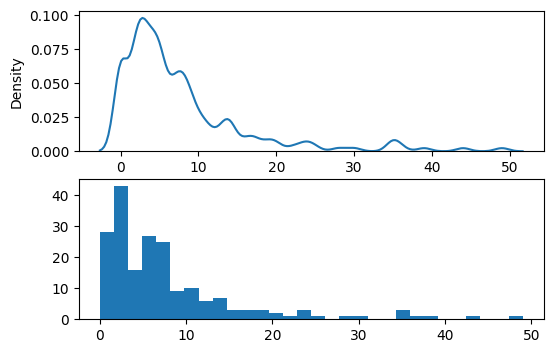

In [ ]:
fig, axes = plt.subplots(2,1, figsize=(6,4))
sns.kdeplot(df['pts'], bw_adjust=.3, ax=axes[0])
axes[1].hist(df['pts'], bins=30)
plt.show()

C:\Users\jacob\AppData\Local\Temp\ipykernel_25544\2284311598.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,1].boxplot(


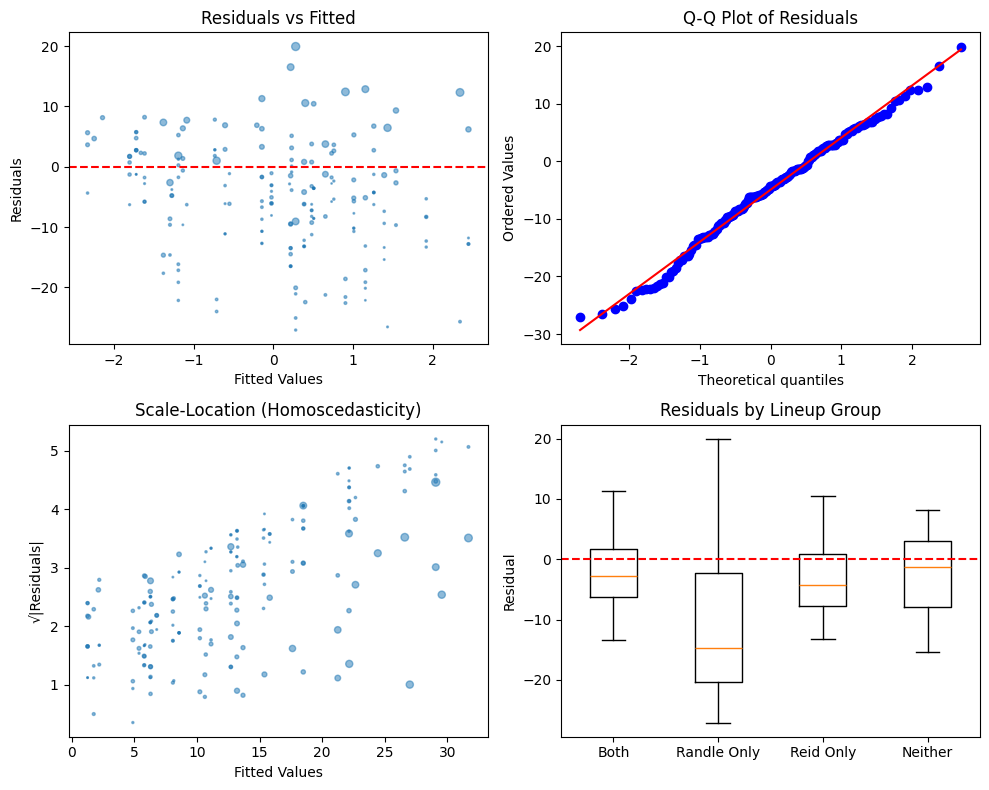

Breusch-Pagan: stat=107.572, p=0.0000
HC3/cluster SEs are warranted


In [ ]:
pts_fitted = pts_res.fittedvalues
pts_resid  = pts_res.resid
weights = df["min"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# 1. Residuals vs Fitted — checks linearity and homoscedasticity
axes[0,0].scatter(fitted, pts_resid, alpha=0.5, s=weights*2)
axes[0,0].axhline(0, color='red', linestyle='--')
axes[0,0].set_xlabel("Fitted Values")
axes[0,0].set_ylabel("Residuals")
axes[0,0].set_title("Residuals vs Fitted")

# 2. Q-Q Plot — checks normality of residuals (expect deviation given JB result)
stats.probplot(pts_resid, dist="norm", plot=axes[0,1])
axes[0,1].set_title("Q-Q Plot of Residuals")

# 3. Scale-Location — checks homoscedasticity
axes[1,0].scatter(pts_fitted, np.sqrt(np.abs(pts_resid)), alpha=0.5, s=weights*2)
axes[1,0].set_xlabel("Fitted Values")
axes[1,0].set_ylabel("√|Residuals|")
axes[1,0].set_title("Scale-Location (Homoscedasticity)")

# 4. Residuals by lineup group — key diagnostic for your hypothesis
df["pts_resid"] = pts_resid.values
groups = {
    "Both":        df["randle_reid"] == 1,
    "Randle Only": (df["randle"] == 1) & (df["randle_reid"] == 0),
    "Reid Only":   (df["reid"]   == 1) & (df["randle_reid"] == 0),
    "Neither":     (df["randle"] == 0) & (df["reid"] == 0),
}
axes[1,1].boxplot(
    [df.loc[mask, "pts_resid"].values for mask in groups.values()],
    labels=groups.keys()
)
axes[1,1].axhline(0, color='red', linestyle='--')
axes[1,1].set_title("Residuals by Lineup Group")
axes[1,1].set_ylabel("Residual")

plt.tight_layout()
plt.show()

# Breusch-Pagan formal heteroscedasticity test
from statsmodels.stats.diagnostic import het_breuschpagan
bp_stat, bp_p, _, _ = het_breuschpagan(pts_resid, pts_res.model.exog)
print(f"Breusch-Pagan: stat={bp_stat:.3f}, p={bp_p:.4f}")
print("HC3/cluster SEs are warranted" if bp_p < 0.05 else "Homoscedastic — SEs valid either way")

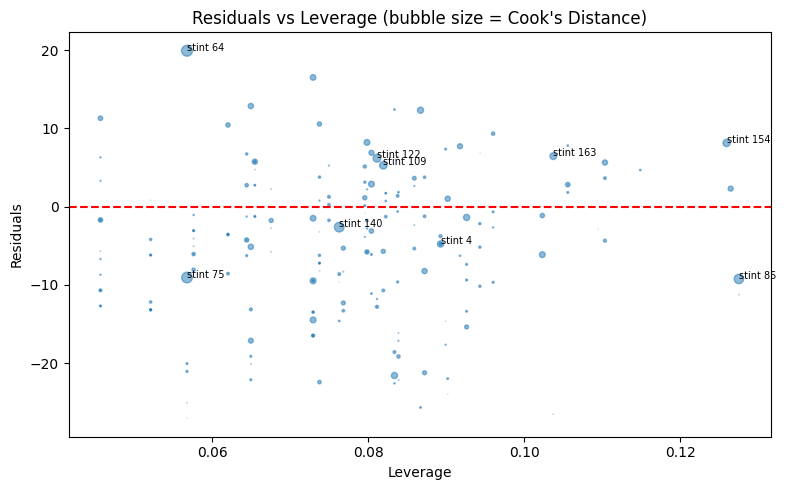

High influence stints (Cook's D > 0.020): 9
Max Cook's Distance: 0.0624


In [ ]:
# OLSInfluence works on the underlying OLS model object
pts_influence = OLSInfluence(pts_res)
pts_leverage  = influence.hat_matrix_diag
pts_cooks_d   = influence.cooks_distance[0]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(pts_leverage, pts_res.resid, s=pts_cooks_d * 1000, alpha=0.5)
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel("Leverage")
ax.set_ylabel("Residuals")
ax.set_title("Residuals vs Leverage (bubble size = Cook's Distance)")

# Mark high-influence points (Cook's D > 4/n threshold)
pts_threshold = 4 / len(pts_res.resid)
pts_high_influence = np.where(pts_cooks_d > pts_threshold)[0]
for i in pts_high_influence:
    ax.annotate(f"stint {i}", (pts_leverage[i], pts_res.resid.iloc[i]), fontsize=7)

plt.tight_layout()
plt.show()

print(f"High influence stints (Cook's D > {pts_threshold:.3f}): {len(pts_high_influence)}")
print(f"Max Cook's Distance: {pts_cooks_d.max():.4f}")

In [ ]:
import numpy as np
import pandas as pd

# Build the exact design matrix your formula creates
X = pd.get_dummies(
    df[['randle', 'reid', 'randle_reid', 'opponent_team_id']],
    columns=['opponent_team_id'],
    drop_first=True
).astype(float)

# Add intercept
X.insert(0, 'intercept', 1.0)

# Singular Value Decomposition — near-zero singular values = redundant columns
_, singular_values, Vt = np.linalg.svd(X.values)

print("Singular values (near-zero = problematic):")
for i, sv in enumerate(singular_values):
    flag = "  ← NEAR ZERO" if sv < 1e-10 else ""
    print(f"  {sv:>12.6f}{flag}")

# Find which columns are involved in the redundancy
# The right singular vectors corresponding to near-zero values
# point to the collinear columns
zero_idx = np.where(singular_values < 1e-10)[0]
for idx in zero_idx:
    dominant_cols = np.abs(Vt[idx])
    top_cols = np.argsort(dominant_cols)[::-1][:3]
    print(f"\nRedundancy {idx} involves columns:")
    for c in top_cols:
        print(f"  {X.columns[c]}: weight={dominant_cols[c]:.4f}")

Singular values (near-zero = problematic):
     20.692460
      7.383771
      6.870628
      4.944633
      4.389022
      4.261342
      4.063580
      3.952969
      3.823364
      3.744551
      3.707503
      3.593392
      3.469435
      1.913671
      1.043543


In [ ]:
df['ptsa'] = df['pts'] - df['plus_minus']
df['ptsa_per_min'] = df['ptsa'] / df['min']
ptsa_model = smf.wls('ptsa_per_min ~ reid + randle + randle_reid + C(opponent_team_id)', data = df, weights= df['min'])
ptsa_results = ptsa_model.fit(cov_type="cluster", cov_kwds={"groups": df["game_id"]})
print(ptsa_results.summary())

                            WLS Regression Results                            
Dep. Variable:           ptsa_per_min   R-squared:                       0.075
Model:                            WLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.212
Date:                Tue, 17 Feb 2026   Prob (F-statistic):             0.0114
Time:                        21:56:05   Log-Likelihood:                -316.72
No. Observations:                 196   AIC:                             663.4
Df Residuals:                     181   BIC:                             712.6
Df Model:                          14                                         
Covariance Type:              cluster                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

C:\Projects\bulls-analytics\.venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 14, but rank is 4
  warnings.warn('covariance of constraints does not have full '


In [ ]:
models = {
    'pts':        smf.wls('pts ~ reid + randle + randle_reid + C(opponent_team_id)', 
                           data=df, weights=df['min'])
                  .fit(cov_type="cluster", cov_kwds={"groups": df["game_id"]}),

    'ptsa':       smf.wls('ptsa ~ reid + randle + randle_reid + C(opponent_team_id)', 
                           data=df, weights=df['min'])
                  .fit(cov_type="cluster", cov_kwds={"groups": df["game_id"]}),

    'plus_minus': smf.wls('plus_minus ~ reid + randle + randle_reid + C(opponent_team_id)', 
                           data=df, weights=df['min'])
                  .fit(cov_type="cluster", cov_kwds={"groups": df["game_id"]}),
}

vars_of_interest = ['randle_reid', 'randle', 'reid']

print(f"\n{'Variable':<15} {'PTS coef (p)':>16} {'PTSA coef (p)':>16} {'PM coef (p)':>16} {'Implied PM':>12}")
print("-" * 77)

for var in vars_of_interest:
    c_pts  = models['pts'].params[var]
    p_pts  = models['pts'].pvalues[var]
    c_ptsa = models['ptsa'].params[var]
    p_ptsa = models['ptsa'].pvalues[var]
    c_pm   = models['plus_minus'].params[var]
    p_pm   = models['plus_minus'].pvalues[var]
    implied = c_pts - c_ptsa   # must equal c_pm

    print(f"{var:<15} "
          f"{c_pts:>+7.3f} ({p_pts:.3f})  "
          f"{c_ptsa:>+7.3f} ({p_ptsa:.3f})  "
          f"{c_pm:>+7.3f} ({p_pm:.3f})  "
          f"{implied:>+10.3f}")


Variable            PTS coef (p)    PTSA coef (p)      PM coef (p)   Implied PM
-----------------------------------------------------------------------------
randle_reid     -16.788 (0.000)  -13.374 (0.000)   -3.413 (0.433)      -3.413
randle          +16.295 (0.000)  +12.964 (0.000)   +3.332 (0.299)      +3.332
reid             +0.421 (0.871)   -1.611 (0.344)   +2.032 (0.529)      +2.032
